# Estadistica Aplicada

# PIA - Modelos de Supervivencia

## Equipo - Conecta Mente
* Alejandro Luna Alejos - 1874612
* Jazmin Alessandra Gonzalez Rodriguez - 1989943
* Bryan Alejandro Estrada Rodriguez - 1844554
* Humberto Ceniceros Preciado - 1903633

**Grupo: 042**

## **1. Añadirás una primera parte a la notebook llamada introducción. Hablaras del problema de supervivencia que te toco analizar: ¿qué mide? ¿cuál es el evento? ¿qué tiempo es el que se mide?**

## Introducción

La base de datos a analizar se llama "credit_risk" (Riesgo de credito) la cual se compone de de 1000 clientes de un banco, los cuales dieron información clave al banco para que este pueda decidir si darles x o y cantidad de credito.

***¿Qué mide?:*** Mide el tiempo que lleva el credito (tanto los que ya se pagaron como los que no), la cantidad del monto autorizado, si ya se pago el credito, entre muchisimás cosas más.

***¿Cuál es el evento?:*** El evento es si el credito ya fue pagado

***¿Qué tiempo es el que se mide?:*** El tiempo esta medido en meses

## **2. Comenta quien podría estar interesado en el análisis de supervivencia de tu base de datos, y por qué consideras importante realizar un modelo de supervivencia para tu base de datos (¿qué nos permite conocer o saber?)**

***¿Quién podria estar interesado en este análisis?:*** Principalmente pensamos en bancos que quieran conocer que tan probable es que los clientes comunes puedan pagar sus creditos pero esto se puede llevar de manera similar a bancos dedicados a dar creditos a empresas.

***¿Por qué es importante realizar este modelo para tu base de datos?:*** Como mencionamos anteriormente, nos permite conocer que tan probable es que un cliente de ciertas caracteristicas pague un credito otorgado por una cierta cantidad. Es importante realizar este ejercicio ya que como futuros Actuarios es casi seguro que nos tocaran situaciones reales y hay que saber darles una solución  

## **3. Comenta si tu base de datos posee censura (y en tu caso qué significa la censura para tu base de datos en particular)**

In [2]:
# Librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
# Importamos la base de datos y verificamos
Df_banco = pd.read_csv("https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/credit_risk.csv")
Df_banco.head()

,saldo_cuenta,meses,historia_crediticia,uso,cantidad,saldo_cuenta_ahorro,años_trabajando,tasa_de_interes,genero_estado_civil,aval,...,activos,edad,planes_de_pago,casa,numero_creditos,situacion_laboral,dependientes_economicos,telefono,extranjero,credito_pagado
0,menor_a_cero,6,no_ha_pagado,TV,1169,NaN,mas_de_7,4,hombre_soltero,NaN,...,bienes_raices,67,NaN,propia,2,gobierno,1,1,1,1
1,cero_a_200,48,pago_algun_credito,TV,5951,menor_100,1_a_4,2,mujer_no_soltera,NaN,...,bienes_raices,22,NaN,propia,1,gobierno,1,0,1,0
2,sin_cuenta,12,no_ha_pagado,colegiaturas,2096,menor_100,4_a_7,2,hombre_soltero,NaN,...,bienes_raices,49,NaN,propia,1,obrero,2,0,1,1
3,menor_a_cero,42,pago_algun_credito,mobiliario,7882,menor_100,4_a_7,2,hombre_soltero,aval,...,seguro_vida,45,NaN,prestada,1,gobierno,2,0,1,1
4,menor_a_cero,24,pago_retrasado,coche_nuevo,4870,menor_100,1_a_4,3,hombre_soltero,NaN,...,sin_activos,53,NaN,prestada,2,gobierno,2,0,1,0


In [4]:
Df_banco['credito_pagado'].value_counts()

credito_pagado
1    700
0    300
Name: count, dtype: int64

Efectivamente, la base de datos tiene datos censurados, más especificamente cuenta con 300 datos censurados. Pero ***¿Por qué decimos censurados?*** Bueno, para nosotros que un dato este censurado aquel que tiene un 0 (ya sea por que el evento nunca ocurrio o por que sale del rango de tiempo analizado).

## **4. Conviertelas variables categóricasa dummies.**

In [4]:
## Verificamos las variables categoricas
Df_banco.dtypes

saldo_cuenta               object
meses                       int64
historia_crediticia        object
uso                        object
cantidad                    int64
saldo_cuenta_ahorro        object
años_trabajando            object
tasa_de_interes             int64
genero_estado_civil        object
aval                       object
años_actual_domicilio       int64
activos                    object
edad                        int64
planes_de_pago             object
casa                       object
numero_creditos             int64
situacion_laboral          object
dependientes_economicos     int64
telefono                    int64
extranjero                  int64
credito_pagado              int64
dtype: object

In [10]:
# Convertimos las Variables que no son numericas
Df_banco = pd.get_dummies(Df_banco,drop_first=True).astype("int64")
Df_banco.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 44 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   meses                                   1000 non-null   int64
 1   cantidad                                1000 non-null   int64
 2   tasa_de_interes                         1000 non-null   int64
 3   años_actual_domicilio                   1000 non-null   int64
 4   edad                                    1000 non-null   int64
 5   numero_creditos                         1000 non-null   int64
 6   dependientes_economicos                 1000 non-null   int64
 7   telefono                                1000 non-null   int64
 8   extranjero                              1000 non-null   int64
 9   credito_pagado                          1000 non-null   int64
 10  saldo_cuenta_mas_de_200                 1000 non-null   int64
 11  saldo_cuenta_menor

In [11]:
Df_banco.isnull().sum()

meses                                     0
cantidad                                  0
tasa_de_interes                           0
años_actual_domicilio                     0
edad                                      0
numero_creditos                           0
dependientes_economicos                   0
telefono                                  0
extranjero                                0
credito_pagado                            0
saldo_cuenta_mas_de_200                   0
saldo_cuenta_menor_a_cero                 0
saldo_cuenta_sin_cuenta                   0
historia_crediticia_pago_algun_credito    0
historia_crediticia_pago_retrasado        0
historia_crediticia_pago_todos            0
historia_crediticia_sin_creditos          0
uso_coche_nuevo                           0
uso_coche_usado                           0
uso_colegiaturas                          0
uso_mobiliario                            0
uso_otros                                 0
uso_poner_negocio               

## **5. Cercióratede  no  tener  missing  values o  valores  repetidos,  en  caso  de tenerlos corrige la base de datos**

In [12]:
# Buscamos datos perdidos
Df_banco.isnull().sum()

meses                                     0
cantidad                                  0
tasa_de_interes                           0
años_actual_domicilio                     0
edad                                      0
numero_creditos                           0
dependientes_economicos                   0
telefono                                  0
extranjero                                0
credito_pagado                            0
saldo_cuenta_mas_de_200                   0
saldo_cuenta_menor_a_cero                 0
saldo_cuenta_sin_cuenta                   0
historia_crediticia_pago_algun_credito    0
historia_crediticia_pago_retrasado        0
historia_crediticia_pago_todos            0
historia_crediticia_sin_creditos          0
uso_coche_nuevo                           0
uso_coche_usado                           0
uso_colegiaturas                          0
uso_mobiliario                            0
uso_otros                                 0
uso_poner_negocio               

In [13]:
Df_banco.duplicated().sum()

0

## **6. Calcula las estadísticas descriptivas de las variables.**

In [14]:
Df_banco.describe()

,meses,cantidad,tasa_de_interes,años_actual_domicilio,edad,numero_creditos,dependientes_economicos,telefono,extranjero,credito_pagado,...,genero_estado_civil_mujer_no_soltera,activos_otro_tipo,activos_seguro_vida,activos_sin_activos,planes_de_pago_departamental,casa_propia,casa_renta,situacion_laboral_desempleado,situacion_laboral_gobierno,situacion_laboral_obrero
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000
mean,20.903000,3271.258000,2.973000,2.845000,35.546000,1.407000,1.155000,0.404000,0.963000,0.700000,...,0.310000,0.332000,0.23200,0.154000,0.047000,0.713000,0.179000,0.022000,0.630000,0.2000
std,12.058814,2822.736876,1.118715,1.103718,11.375469,0.577654,0.362086,0.490943,0.188856,0.458487,...,0.462725,0.471167,0.42232,0.361129,0.211745,0.452588,0.383544,0.146757,0.483046,0.4002
min,4.000000,250.000000,1.000000,1.000000,19.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
25%,12.000000,1365.500000,2.000000,2.000000,27.000000,1.000000,1.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000
50%,18.000000,2319.500000,3.000000,3.000000,33.000000,1.000000,1.000000,0.000000,1.000000,1.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.0000
75%,24.000000,3972.250000,4.000000,4.000000,42.000000,2.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,0.00000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.0000
max,72.000000,18424.000000,4.000000,4.000000,75.000000,4.000000,2.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000


## **7. Calcula lo siguiente**

### **a) Cuantas variables y cuantas observaciones tienen la base**

In [19]:
print("Se tienen", len(Df_banco.columns), " variables en total, contando los dummies")
print("El numero de observaciones en cada variable es de:", len(Df_banco))

Se tienen 44  variables en total, contando los dummies
El numero de observaciones en cada variable es de: 1000


Por lo tanto venemos 44 variables con 1000 observaciones

### **b) Cuál es el monto promedio de los créditos otorgados por el banco**

In [46]:
print("El monto promedio prestado por el banco es de:", Df_banco["cantidad"].mean())

El monto promedio prestado por el banco es de: 3271.258


### **c) Cuál es el tiempo promedio que se tardaron en pagar el préstamo los que pagaron el préstamo en su totalidad**

In [22]:
print("El tiempo promedio que se tardaron en liquidar sus prestamos, los que ya los liquidaron por completo, es de:", Df_banco.query("credito_pagado==1")["meses"].mean().round(2), "meses")

El tiempo promedio que se tardaron en liquidar sus prestamos, los que ya los liquidaron por completo, es de: 19.21 meses


### **d) Cuál es la tasa de interés promedio otorgada por el banco**

In [23]:
print("La tasa de interes promedio que se les otorga a los clientes es de:", Df_banco["tasa_de_interes"].mean(), "%")

La tasa de interes promedio que se les otorga a los clientes es de: 2.973 %


### **e) Cuál es el monto promedio y la tasa de interés promedio de los que ya pagaron**

In [25]:
print("El monto promedio prestado a los que ya pagaron su prestamo fue de:", Df_banco.query("credito_pagado==1")["cantidad"].mean().round(3))
print("con una tasa de interes de:", Df_banco.query("credito_pagado==1")["tasa_de_interes"].mean(),"%")

El monto promedio prestado a los que ya pagaron su prestamo fue de: 2985.457
con una tasa de interes de: 2.92 %


### **f) Cuál es el monto promedio y la tasa de interés promedio de los que no han pagado**

In [24]:
print("El monto promedio prestado a los que ya pagaron su prestamo fue de:", Df_banco.query("credito_pagado==0")["cantidad"].mean().round(3))
print("con una tasa de interes de:", Df_banco.query("credito_pagado==0")["tasa_de_interes"].mean().round(3),"%")

El monto promedio prestado a los que ya pagaron su prestamo fue de: 3938.127
con una tasa de interes de: 3.097 %


## **8. Calcula el tiempo promedio de supervivencia de la base de datos**

In [51]:
print("El tiempo promedio de supervivencia de la base de datos es de:", Df_banco["meses"].mean())

El tiempo promedio de supervivencia de la base de datos es de: 20.903


c:\Users\Alejandro\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


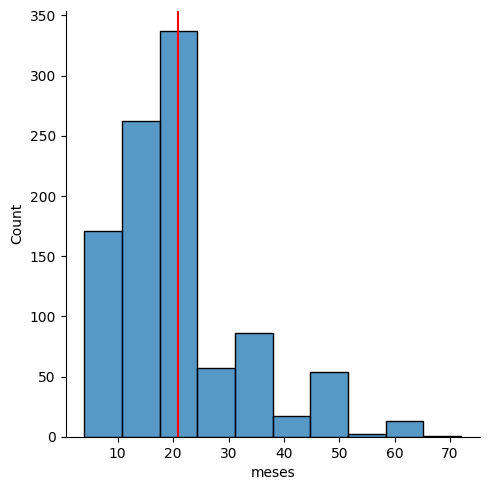

In [51]:
sns.displot(Df_banco["meses"], bins=10)
plt.axvline(20.903, color='red')
plt.show()

## **9. Calcula la función de supervivencia y grafícala utilizando Kaplan-Meier y obtén la mediana ¿qué significa la mediana?**

In [9]:
from lifelines import KaplanMeierFitter

km1 = KaplanMeierFitter().fit(Df_banco["meses"], Df_banco["credito_pagado"])
km1.survival_function_

,KM_estimate
timeline,
0.0,1.000000
4.0,0.994000
5.0,0.993000
6.0,0.927000
7.0,0.921951
8.0,0.915892
9.0,0.880510
10.0,0.854824
11.0,0.845544


Text(0, 0.5, 'KM_estimate')

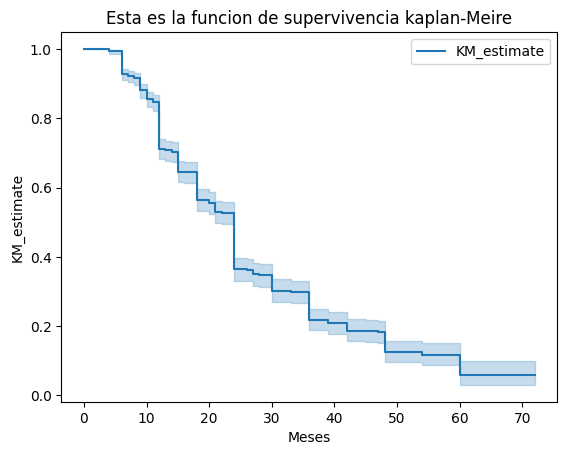

In [53]:
km1.plot_survival_function()
plt.title('Esta es la funcion de supervivencia kaplan-Meire')
plt.xlabel('Meses')
plt.ylabel('KM_estimate')

In [54]:
km1.median_survival_time_

24.0

Lo cual nos quiere decir que la mitad de los creditos otorgados son pagados para el mes 24 o que la mitad de los creditos otorgados no se han pagado para el mes 24

## **10. Elige construye una variable (por ejemplo, para la del crédito bancario, si debe másde 500 mil 1, y 0 si debe menos), estima y grafica la función de supervivenciapor Kaplan-meierpara cada grupo**

In [16]:
promedio = Df_banco['cantidad'].mean()

In [7]:
# Creamos una variable 'credito_bancario'
Df_banco['credito_bancario'] = (Df_banco['cantidad'] > promedio).astype(int)

In [11]:
## Divide los datos en dos grupos basados en 'credito_bancario'
grupo_0 = Df_banco[Df_banco['credito_bancario'] == 0]
grupo_1 = Df_banco[Df_banco['credito_bancario'] == 1]

In [15]:
km2 = KaplanMeierFitter().fit(grupo_0['meses'], grupo_0['credito_pagado'], label='Debe menos de 3,271.258')
km3 = KaplanMeierFitter().fit(grupo_1['meses'], grupo_1['credito_pagado'], label='Debe mas de 3,271.258')

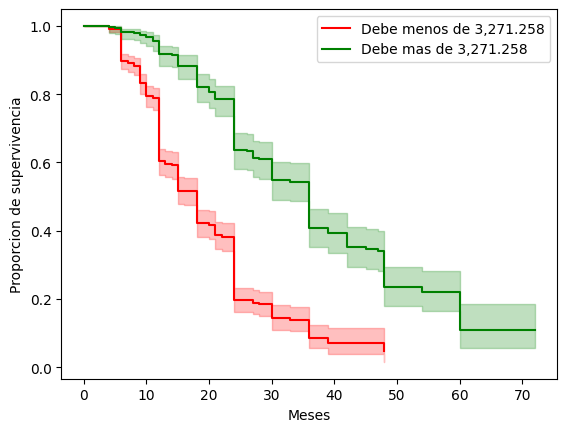

In [14]:
km2.plot_survival_function(label = 'Debe menos de 3,271.258', color='red')
km3.plot_survival_function(label = 'Debe mas de 3,271.258', color='green')
plt.xlabel('Meses')
plt.ylabel('Proporcion de supervivencia');

El gráfico muestra cómo cambia la proporción de personas que han pagado su préstamo en su totalidad a medida que pasa el tiempo para cada grupo. Esto nos permite comparar el rendimiento de los dos grupos en términos de pago del préstamo a lo largo del tiempo y ver si hay diferencias significativas en la supervivencia del préstamo entre las personas con deudas mayores y menores al promedio.

## **11. Prueba Si las funciones de supervivencia son distintas usando el log rank test y comenta el resultado**

Para verificar que las funciones sean diferentes se crea una prueba de hipotesis

Prueba de hipotesis se llama **Log-rank-test**

$Ho: S(1) = S(2)$

$Ha: S(1) \neq S(2)$

In [60]:
from lifelines.statistics import logrank_test
LRT = logrank_test(grupo_0['meses'], grupo_1['meses'], grupo_0['credito_pagado'], grupo_1['credito_pagado'])

In [61]:
LRT.print_summary()

<lifelines.StatisticalResult: logrank_test>
               t_0 = -1
 null_distribution = chi squared
degrees_of_freedom = 1
         test_name = logrank_test

---
 test_statistic      p  -log2(p)
         185.72 <0.005    138.07

In [62]:
LRT.p_value.round(2)

0.0

p.value = 0.0 < 0.05 = alfa

RECHAZAMOS H0, Con un alto grado de confianza (95% de confianza), podemos afirmar que hay diferencias significativas en el tiempo que toma pagar los préstamos entre estos dos grupos. Los resultados respaldan la idea de que las personas con deudas mayores al promedio tienden a requerir más tiempo para completar sus pagos en comparación con aquellas con deudas menores al promedio.

## **12. Ahora estima un modelo de Cox**

### **a) A parte de “tasa de interes” y “cantidad”, elige otras cuatro variables que creas que afectan el riesgo del evento**

Tomaremos las variables:
1. "activos",
2. "numero_creditos",
3. "situacion_laboral"
4. "casa"

In [63]:
Df_banco = pd.read_csv("https://raw.githubusercontent.com/jimmyzac/Estadistica-Aplicada-FCFM-UANL/main/bases_datos/credit_risk.csv")
Df_6Varibles = Df_banco[["meses", "credito_pagado", "cantidad", "tasa_de_interes", "activos", "numero_creditos", "situacion_laboral", "casa"]]
Df_6Varibles

,meses,credito_pagado,cantidad,tasa_de_interes,activos,numero_creditos,situacion_laboral,casa
0,6,1,1169,4,bienes_raices,2,gobierno,propia
1,48,0,5951,2,bienes_raices,1,gobierno,propia
2,12,1,2096,2,bienes_raices,1,obrero,propia
3,42,1,7882,2,seguro_vida,1,gobierno,prestada
4,24,0,4870,3,sin_activos,2,gobierno,prestada
...,...,...,...,...,...,...,...,...
995,12,1,1736,3,bienes_raices,1,obrero,propia
996,30,1,3857,4,seguro_vida,1,administrativo,propia
997,12,1,804,4,otro_tipo,1,gobierno,propia
998,45,0,1845,4,sin_activos,1,gobierno,prestada


### **b) Di si cada una de las 6 variables que elegiste, aumentan/disminuyen el riesgo del evento y por qué**

La variable ***"activos"*** debe de **AUMENTAR** el riesgo de que el cliente SI pague el prestamo completamente ya que al tener activos nos indica que la persona pudo haber invertido el dinero prestado a otros bienes que le generan más dinero del que va a terminar pagando

La varibale ***"numero_creditos"*** debde de **DISMINUIR** el riesgo de que el cliente SI pague el prestamo completamente por que si una persona tiene más de un credito sigifica que no tiene la suficiente solvencia para terminar de pagar el anterior.

La variable ***"situación_laboral"*** debe de **AUMENTAR** el riesgo de que el cliente SI pague el prestamo completamente ya que muchos de los clientes que tienen un trabajo podrian pagar sus deudas

La variable ***"casa"*** debe de **AUMENTAR** el riesgo de que el cliente SI pague el prestamo completamente ya que significa si el cliente tiene una casa propia no tiene el gasto de estar rentando y ese dinero lo puede usar en otras cosas.

La variable ***"tasa_de_interes"*** debe de **DISMINUIR** el riesgo de que el cliente SI pague el prestamo completamente por que a mayor tasa de interes más terminara pagando el cliente y eso los puede desalentar a seguir pagando o ha pagar el prestamo.

La variable ***"cantidad"*** debe de **DISMINUIR** el riesgo de que el cliente SI pague el prestamo completamente por que a mayor cantidad de prestamo más terminara más terminara pagando.

### **c) Realiza  las  transformaciones  adecuadas  para  utilizar  las  variables en un modelo de cox**

In [64]:
from lifelines import CoxPHFitter

# Verificamos si existen valores nulos
# si existen en la base de datos elegida
# los depuramos

Df_6Varibles.isnull().sum()

meses                0
credito_pagado       0
cantidad             0
tasa_de_interes      0
activos              0
numero_creditos      0
situacion_laboral    0
casa                 0
dtype: int64

In [65]:
# Verificamos que no haya valores duplicados
# y si los hay, los eliminamos

Df_6Varibles.duplicated().sum()

0

In [66]:
# Verificamos que tipos son y si no son numericas las hacemos
Df_6Varibles.dtypes

meses                 int64
credito_pagado        int64
cantidad              int64
tasa_de_interes       int64
activos              object
numero_creditos       int64
situacion_laboral    object
casa                 object
dtype: object

In [67]:
# Convertimos las Variables que no son numericas
Df_6Varibles = pd.get_dummies(Df_6Varibles,drop_first=True)
Df_6Varibles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   meses                          1000 non-null   int64
 1   credito_pagado                 1000 non-null   int64
 2   cantidad                       1000 non-null   int64
 3   tasa_de_interes                1000 non-null   int64
 4   numero_creditos                1000 non-null   int64
 5   activos_otro_tipo              1000 non-null   bool 
 6   activos_seguro_vida            1000 non-null   bool 
 7   activos_sin_activos            1000 non-null   bool 
 8   situacion_laboral_desempleado  1000 non-null   bool 
 9   situacion_laboral_gobierno     1000 non-null   bool 
 10  situacion_laboral_obrero       1000 non-null   bool 
 11  casa_propia                    1000 non-null   bool 
 12  casa_renta                     1000 non-null   bool 
dtypes: bool(8), int64(5

In [68]:
Df_6Varibles.describe()

,meses,credito_pagado,cantidad,tasa_de_interes,numero_creditos
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,20.903000,0.700000,3271.258000,2.973000,1.407000
std,12.058814,0.458487,2822.736876,1.118715,0.577654
min,4.000000,0.000000,250.000000,1.000000,1.000000
25%,12.000000,0.000000,1365.500000,2.000000,1.000000
50%,18.000000,1.000000,2319.500000,3.000000,1.000000
75%,24.000000,1.000000,3972.250000,4.000000,2.000000
max,72.000000,1.000000,18424.000000,4.000000,4.000000


### **d) Estima un modelo de cox con las variables elegidas e interpreta los coeficientes**

In [69]:
Cph = CoxPHFitter().fit(Df_6Varibles, "meses", "credito_pagado")
Cph.print_summary()

<lifelines.CoxPHFitter: fitted with 1000 total observations, 300 right-censored observations>
             duration col = 'meses'
                event col = 'credito_pagado'
      baseline estimation = breslow
   number of observations = 1000
number of events observed = 700
   partial log-likelihood = -4050.35
         time fit was run = 2023-11-12 05:39:06 UTC

---
                                coef  exp(coef)   se(coef)   coef lower 95%   coef upper 95%  exp(coef) lower 95%  exp(coef) upper 95%
covariate                                                                                                                             
cantidad                       -0.00       1.00       0.00            -0.00            -0.00                 1.00                 1.00
tasa_de_interes                -0.38       0.68       0.04            -0.46            -0.31                 0.63                 0.73
numero_creditos                 0.17       1.19       0.07             0.04             0.30                 1.04                 1.35
activos_otro_tipo              -0.34       0.71       0.10            -0.53            -0.15                 0.59                 0.86
activos_seguro_vida            -0.22       0.81       0.10            -0.42            -0.01                 0.66                 0.99
activos_sin_activos            -0.50       0.60       0.20            -0.89            -0.11                 0.41                 0.89
situacion_laboral_desempleado  -0.48       0.62       0.29            -1.05             0.09                 0.35                 1.09
situacion_laboral_gobierno     -0.34       0.71       0.12            -0.56            -0.11                 0.57                 0.89
situacion_laboral_obrero       -0.13       0.87       0.14            -0.41             0.14                 0.67                 1.15
casa_propia                    -0.01       0.99       0.21            -0.43             0.41                 0.65                 1.51
casa_renta                     -0.15       0.86       0.22            -0.59             0.29                 0.56                 1.33

                                cmp to      z      p   -log2(p)
covariate                                                      
cantidad                          0.00 -15.27 <0.005     172.52
tasa_de_interes                   0.00 -10.36 <0.005      81.20
numero_creditos                   0.00   2.57   0.01       6.61
activos_otro_tipo                 0.00  -3.53 <0.005      11.21
activos_seguro_vida               0.00  -2.06   0.04       4.65
activos_sin_activos               0.00  -2.53   0.01       6.47
situacion_laboral_desempleado     0.00  -1.67   0.10       3.38
situacion_laboral_gobierno        0.00  -2.92 <0.005       8.16
situacion_laboral_obrero          0.00  -0.97   0.33       1.60
casa_propia                       0.00  -0.04   0.97       0.05
casa_renta                        0.00  -0.67   0.50       0.99
---
Concordance = 0.78
Partial AIC = 8122.69
log-likelihood ratio test = 438.08 on 11 df
-log2(p) of ll-ratio test = 286.70

In [70]:
print(Cph.params_)
print(" ")
print(Cph.hazard_ratios_)

covariate
cantidad                        -0.000374
tasa_de_interes                 -0.384348
numero_creditos                  0.171179
activos_otro_tipo               -0.343322
activos_seguro_vida             -0.215318
activos_sin_activos             -0.504714
situacion_laboral_desempleado   -0.482723
situacion_laboral_gobierno      -0.337662
situacion_laboral_obrero        -0.134748
casa_propia                     -0.009203
casa_renta                      -0.149297
Name: coef, dtype: float64
 
covariate
cantidad                         0.999626
tasa_de_interes                  0.680894
numero_creditos                  1.186703
activos_otro_tipo                0.709410
activos_seguro_vida              0.806285
activos_sin_activos              0.603678
situacion_laboral_desempleado    0.617100
situacion_laboral_gobierno       0.713436
situacion_laboral_obrero         0.873936
casa_propia                      0.990840
casa_renta                       0.861314
Name: exp(coef), dtype: flo

1. La variable $cantidad$ tiene un p-value de **<0.005**, por lo que **rechazamos H0**. Por lo tanto, la $cantidad$ de dinero prestado **DIMINUYE** el riesgo de que el cliente pague el prestamo otorgado por el banco en un **0.0374%** por cada x peso/s.

2. La variable $tasa$ $de$ $interes$ tiene un p-value de **<0.005**, por lo que **rechazamos H0**. Por lo tanto, la $tasa de interes$ **DIMINUYE** el riesgo de que el cliente pague el prestamo otorgado por el banco en un **32%** por cada punto de interes.

3. La variable $numero$ $creditos$ tiene un p-value de **0.01**, por lo que **rechazamos H0**. Por lo tanto, el $numero$ $creditos$ **AUMENTA** el riesgo de que el cliente pague el prestamo otorgado por el banco en un **19%** por cada credito otorgado.

4. La variable $Casa$ $propia$ tiene un p-value de **.97**, por lo que **no rechazamos H0**. Por lo tanto, no tiene efecto en el riesgo.

5. La variable $Casa$ $renta$ tiene un p-value de **0.50**, por lo que **no rechazamos H0**. Por lo tanto, no tiene efecto en el riesgo.

6. La variable $Activos$ $en$ $bienes$ $raices$ tiene un p-value de **<0.005**, por lo que **rechazamos H0**. Por lo tanto, tener $Activos$ $en$ $bienes$ $raices$ **AUMENTA** el riesgo en un **41%** a comparación de $Activos en otro tipo$

7. La variable $Activos$ $en$ $seguro $vida$ tiene un p-value de **0.22**, por lo que **no rechazamos H0**. Por lo tanto, no tiene efecto en el riesgo

8. La variable $Activos$ $en$ $sin$ $activos$ tiene un p-value de **0.41**, por lo que **no rechazamos H0**. Por lo tanto, no tiene efecto en el riesgo.

9. La variable $desempleado$ tiene un p-value de **0.10**, por lo que **rechazamos H0**. Por lo tanto, no tiene efecto en el riesgo.

10. La variable $gobierno$ tiene un p-value de **<0.005**, por lo que **rechazamos H0**. Por lo tanto, **DIMINUYE** el riesgo en un **29%** a comparación de $administrativo$

11. La variable $obrero$ tiene un p-value de **0.33**, por lo que **rechazamos H0**. Por lo tanto, no tiene efecto en el riesgo.

## **13. Interpreta cada uno de los coeficientes obtenidos.Utiliza cph.plot()para ayudarte con la interpretación.**

<Axes: xlabel='log(HR) (95% CI)'>

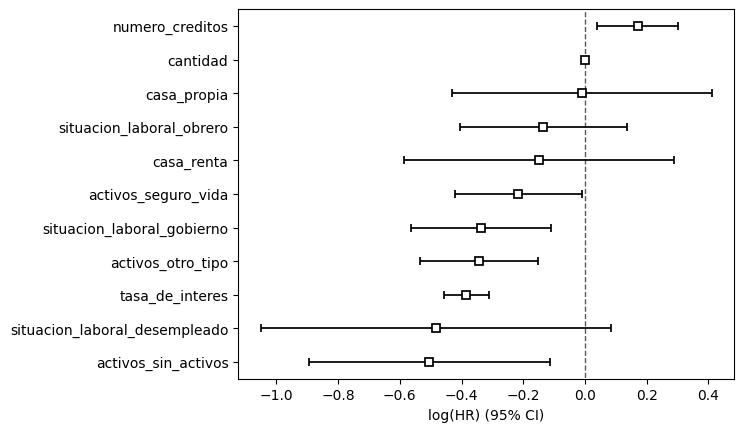

In [71]:
Cph.plot()

Si el intervalo de confianza incluye al 0, entonces la variable es no significativa. 

## **14.Con  base  en  los  cálculos  realizados,  redacta  un  comentario  integral  de por   lo   menos   250   palabras   que   resuma   el   análisis,   reflexiones   y recomendaciones  sobre  la  política  de  otorgamiento  de  créditos  en  el Banco de la Ilusión.**

Empezaría por revisar por que las personas con estatus de situación laboral “desempleado” no afecta el riesgo de que paguen el préstamo otorgado por el banco y que peor aún, las personas que trabajan en “gobierno” tienen que un efecto de disminución. Fuera de eso me parece una muy lógico que a las personas se les otorgue varios créditos a al mismo tiempo a una persona si esa ya tiene un historial crediticio en la empresa y este siempre lo pague en su tiempo y forma.

Una recomendación que le puedo realizar es que tenga más peso los tipos de activos que puede o pretende tener el cliente. El no tenerlo no significa que sea malo o que disminuya el riesgo de que pague el préstamo, pero el tenerlo si debería de aumentar ese mismo riesgo, ya que si se presenta algún imprevisto que requiera de una acción monetaria, el cliente tendrá margen de maniobra de cubrir ese imprevisto sin dejar de lado sus obligaciones con el banco por el préstamo. Esto mismo podría aplicarse, de cierta manera, en que si el cliente es propietario de una casa o no, ya que si lo es significa que parte de lo que gana puede destinarse a seguir cumpliendo sus obligaciones.

**Reflexión:** hay muchas cosas que todavía se pueden mejorar y otras por revisar en el banco, muchas variables que no tienen sentido que no afecten al riesgo (que en primera instancia debería de ser una barrera para no otorgar ese préstamo) y otras que a mi parecer no deben de afectar en la manera en que afecta. Posiblemente no se esté tomando en cuenta todo el panorama o todas las variables.


## **15.Por último,investiga  y  señala  las  limitaciones  de  Kaplan-Meier  y  del modelo de Cox**

***Kaplan-Meier:*** La principal idea que se debe transmitir es que el análisis de supervivencia estándar con métodos actuariales o con estimadores de Kaplan-Meier no es aplicable en presencia de riesgos competitivos de muerte y sobrestima siempre la probabilidad de suceso.
Una importante asunción del método de Kaplan-Meier es que la probabilidad de que una observación sea censurada es independiente del tiempo de supervivencia. Esta asunción puede ser admitida en presencia de censuras no informativas9 (p. ej., si la censura se produce por finalización del estudio). Sin embargo, si la censura se puede producir por otras causas de muerte, la probabilidad puede estar relacionada con el tiempo de supervivencia

https://www.scielosp.org/pdf/gs/2004.v18n5/391-397

***Modelo de Cox:*** Este modelo requiere que se cumplan dos supuestos. El primero es que los datos censurados sean independientes del resultado de interés. Esto no se cumple en el caso de pacientes que, por haber presentado el evento de interés, pierden el seguimiento. El segundo supuesto es que los riesgos sean proporcionales, es decir, que el HR sea constante durante toda la duración del estudio. Esto significa que si aumenta (o disminuye) el riesgo en el grupo expuesto, en forma concomitante debe aumentar (o disminuir) en el grupo comparador, manteniéndose constante la relación entre ambos. Si estos supuestos no se cumplen, los resultados del modelo no son válidos.

https://actagastro.org/introduccion-al-analisis-de-sobrevida/